# Modified TPGMM for Gait Data with Transformed Reference Frame

In [1]:
import sys
import os

import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

print(parent_dir)
print(os.getcwd())

/home/jemajuinta/ws/Gait-analysis-coupled/TaskPaGMMM
/home/jemajuinta/ws/Gait-analysis-coupled/TaskPaGMMM/examples


In [3]:
from tpgmm.tpgmm.tpgmm import TPGMM
from tpgmm.gmr.gmr import GaussianMixtureRegression
from tpgmm.utils.plot.plot import plot_trajectories, plot_ellipsoids, scatter
from tpgmm.utils.plot.plot import plot_trajectories_2d, plot_ellipsoids_2d

In [4]:
with open("7days1/gait_analysis_export_subject35.json", "r") as f:
    data = json.load(f)

with open("7days1/gait_analysis_export_subject35.json", "r") as f:
    data = json.load(f)

Trajectories manipulation

# Create separate lists for trajectories from each frame of reference
trajectories_fr1 = []
trajectories_fr2 = []

# Access kinematics data for FR1 and FR2
fr1_data = data['kinematics_data']['FR1']['right_leg_kinematics']
fr2_data = data['kinematics_data']['FR2']['right_leg_kinematics']

for demo_fr1, demo_fr2 in zip(fr1_data, fr2_data):
    # For FR1: right ankle position and velocity with time
    pos_fr1 = np.array(demo_fr1['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr1 = np.array(demo_fr1['right_ankle_vel']).T  # Shape: (200, 2)
    
    # Create time vector for this demonstration
    num_steps = pos_fr1.shape[0]
    time_demo = np.linspace(0, 1, num_steps).reshape(-1, 1)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, time]
    traj1 = np.hstack([pos_fr1, vel_fr1, time_demo])
    trajectories_fr1.append(traj1)
    
    # For FR2: right ankle position and velocity with time
    pos_fr2 = np.array(demo_fr2['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr2 = np.array(demo_fr2['right_ankle_vel']).T  # Shape: (200, 2)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, time]
    traj2 = np.hstack([pos_fr2, vel_fr2, time_demo])
    trajectories_fr2.append(traj2)

# Convert lists to numpy arrays
trajectories_fr1 = np.array(trajectories_fr1)
trajectories_fr2 = np.array(trajectories_fr2)

print(f"Trajectories FR1 shape: {trajectories_fr1.shape}")
print(f"Trajectories FR2 shape: {trajectories_fr2.shape}")
print(f"Number of demonstrations: {len(trajectories_fr1)}")

In [ ]:
# Apply +18 degree rotation to all FR2 trajectories using homogeneous transformation
rotation_angle_degrees = 18
rotation_angle_rad = np.deg2rad(rotation_angle_degrees)

print(f"Applying +{rotation_angle_degrees}° rotation to FR2 trajectories")
print(f"Rotation angle in radians: {rotation_angle_rad:.4f}")

# Create 2D rotation matrix for position
cos_theta = np.cos(rotation_angle_rad)
sin_theta = np.sin(rotation_angle_rad)

# 2D rotation matrix
rotation_matrix_2d = np.array([
    [cos_theta, -sin_theta],
    [sin_theta,  cos_theta]
])

print(f"2D Rotation matrix:")
print(rotation_matrix_2d)

# Apply rotation to all FR2 trajectories
trajectories_fr2_rotated = []

for i, traj_fr2 in enumerate(trajectories_fr2):
    # Extract position and velocity components
    positions = traj_fr2[:, :2]  # [x_pos, y_pos]
    velocities = traj_fr2[:, 2:4]  # [x_vel, y_vel]
    time_component = traj_fr2[:, 4:5]  # [time]
    
    # Apply rotation to positions and velocities
    # For each time step, apply rotation matrix
    rotated_positions = np.zeros_like(positions)
    rotated_velocities = np.zeros_like(velocities)
    
    for t in range(positions.shape[0]):
        # Rotate position
        rotated_positions[t] = rotation_matrix_2d @ positions[t]
        # Rotate velocity (same transformation as position)
        rotated_velocities[t] = rotation_matrix_2d @ velocities[t]
    
    # Reconstruct trajectory with rotated components
    rotated_trajectory = np.hstack([rotated_positions, rotated_velocities, time_component])
    trajectories_fr2_rotated.append(rotated_trajectory)
    
    if i == 0:  # Print details for first trajectory
        print(f"\nTrajectory {i+1} transformation details:")
        print(f"  Original position range: X[{positions[:, 0].min():.3f}, {positions[:, 0].max():.3f}], Y[{positions[:, 1].min():.3f}, {positions[:, 1].max():.3f}]")
        print(f"  Rotated position range:  X[{rotated_positions[:, 0].min():.3f}, {rotated_positions[:, 0].max():.3f}], Y[{rotated_positions[:, 1].min():.3f}, {rotated_positions[:, 1].max():.3f}]")

# Replace FR2 trajectories with rotated versions
trajectories_fr2 = np.array(trajectories_fr2_rotated)

print(f"\n✅ Rotation transformation completed!")
print(f"FR2 trajectories shape after rotation: {trajectories_fr2.shape}")
print(f"All FR2 trajectories rotated by +{rotation_angle_degrees}° counterclockwise")

In [ ]:
# Apply +18 degree rotation to all FR2 trajectories using homogeneous transformation
rotation_angle_degrees = 18
rotation_angle_rad = np.deg2rad(rotation_angle_degrees)

print(f"Applying +{rotation_angle_degrees}° rotation to FR2 trajectories")
print(f"Rotation angle in radians: {rotation_angle_rad:.4f}")

# Create 2D rotation matrix for position
cos_theta = np.cos(rotation_angle_rad)
sin_theta = np.sin(rotation_angle_rad)

# 2D rotation matrix
rotation_matrix_2d = np.array([
    [cos_theta, -sin_theta],
    [sin_theta,  cos_theta]
])

print(f"2D Rotation matrix:")
print(rotation_matrix_2d)

# Apply rotation to all FR2 trajectories
trajectories_fr2_rotated = []

for i, traj_fr2 in enumerate(trajectories_fr2):
    # Extract position and velocity components
    positions = traj_fr2[:, :2]  # [x_pos, y_pos]
    velocities = traj_fr2[:, 2:4]  # [x_vel, y_vel]
    time_component = traj_fr2[:, 4:5]  # [time]
    
    # Apply rotation to positions and velocities
    # For each time step, apply rotation matrix
    rotated_positions = np.zeros_like(positions)
    rotated_velocities = np.zeros_like(velocities)
    
    for t in range(positions.shape[0]):
        # Rotate position
        rotated_positions[t] = rotation_matrix_2d @ positions[t]
        # Rotate velocity (same transformation as position)
        rotated_velocities[t] = rotation_matrix_2d @ velocities[t]
    
    # Reconstruct trajectory with rotated components
    rotated_trajectory = np.hstack([rotated_positions, rotated_velocities, time_component])
    trajectories_fr2_rotated.append(rotated_trajectory)
    
    if i == 0:  # Print details for first trajectory
        print(f"\nTrajectory {i+1} transformation details:")
        print(f"  Original position range: X[{positions[:, 0].min():.3f}, {positions[:, 0].max():.3f}], Y[{positions[:, 1].min():.3f}, {positions[:, 1].max():.3f}]")
        print(f"  Rotated position range:  X[{rotated_positions[:, 0].min():.3f}, {rotated_positions[:, 0].max():.3f}], Y[{rotated_positions[:, 1].min():.3f}, {rotated_positions[:, 1].max():.3f}]")

# Replace FR2 trajectories with rotated versions
trajectories_fr2 = np.array(trajectories_fr2_rotated)

print(f"\n✅ Rotation transformation completed!")
print(f"FR2 trajectories shape after rotation: {trajectories_fr2.shape}")
print(f"All FR2 trajectories rotated by +{rotation_angle_degrees}° counterclockwise")

Ploting Input Data

NameError: name 'trajectories_fr1' is not defined

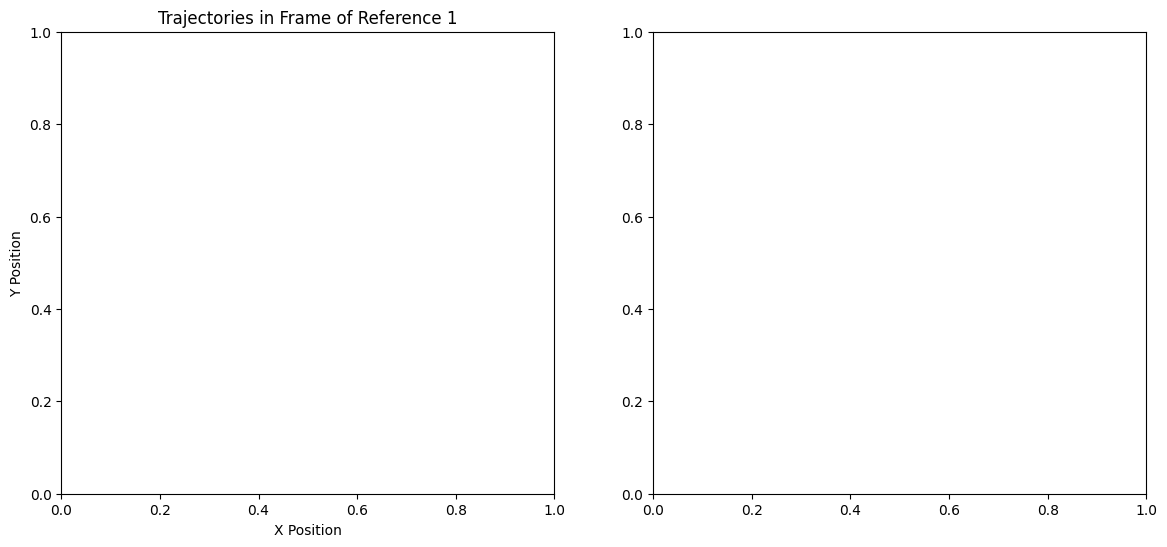

In [5]:
# --- Plotting ---
# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot trajectories for Frame of Reference 1
ax1.set_title('Trajectories in Frame of Reference 1')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
for traj in trajectories_fr1:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax1.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')
for traj in trajectories_fr2:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax2.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
fig.tight_layout()
plt.show()

# Create the figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot X vs Time
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 0], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 0], label='FR2', color='orange')
axs[0].set_title('X vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X')
axs[0].legend()
axs[0].grid()

# Plot Y vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 1], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 1], label='FR2', color='orange')
axs[1].set_title('Y vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

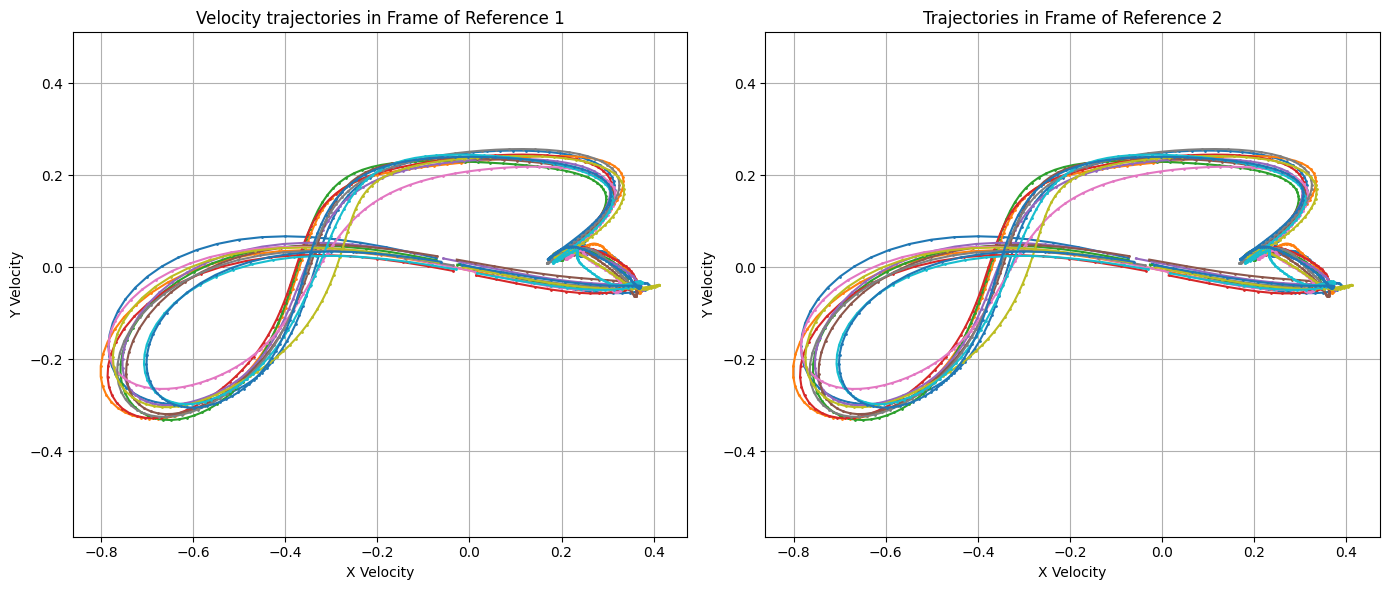

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot velocity trajectories for Frame of Reference 1
ax1.set_title('Velocity trajectories in Frame of Reference 1')
ax1.set_xlabel('X Velocity')
ax1.set_ylabel('Y Velocity')
for traj in trajectories_fr1:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax1.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot velocity trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Velocity')
ax2.set_ylabel('Y Velocity')
for traj in trajectories_fr2:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax2.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
plt.tight_layout()
plt.show()

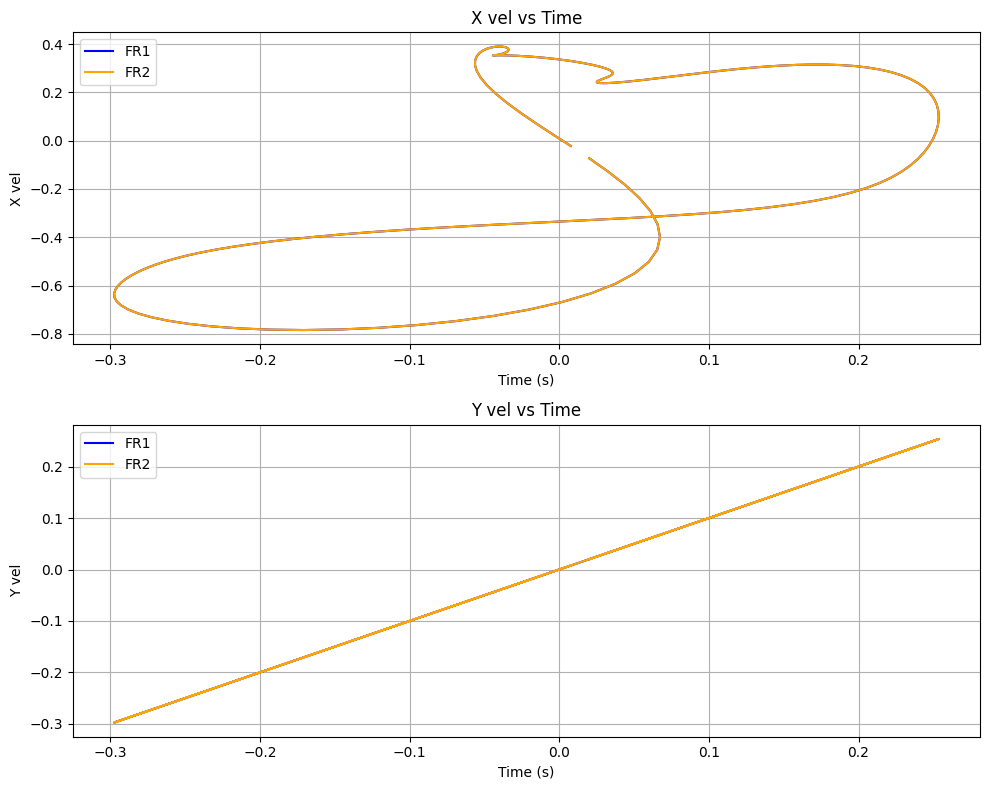

In [ ]:
# Create the figure and subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot X velocity vs Time
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 2], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 2], label='FR2', color='orange')
axs[0].set_title('X vel vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X vel')
axs[0].legend()
axs[0].grid()

# Plot Y velocity vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 3], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 3], label='FR2', color='orange')
axs[1].set_title('Y vel vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y vel')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

TPGMMM

# Reshape the data for TPGMM
# The TPGMM expects data in the shape (num_frames, num_points, num_features)
# We have 2 frames of reference (FR1 and FR2)

# Stack the data for the two frames
num_trajectories, num_samples, num_features = trajectories_fr1.shape
reshaped_trajectories = np.stack([trajectories_fr1, trajectories_fr2], axis=0)

# Reshape to (num_frames, num_trajectories * num_samples, num_features)
reshaped_trajectories = reshaped_trajectories.reshape(2, num_trajectories * num_samples, num_features)

print(f"reshaped trajectories shape: {reshaped_trajectories.shape}")

Fitting TPGMM

In [ ]:
# Model selection using BIC score for different number of components
best_n_components = None
lowest_bic_score = float('inf')
bic_scores = []
n_components_range = range(3, 15)  # Test components from 3 to 14

print("Starting TPGMM model selection...")
print(f"Testing number of components from {min(n_components_range)} to {max(n_components_range)}")
print(f"Data shape: {reshaped_trajectories.shape}")
print("-" * 60)

# Loop through n_components and collect scores for plotting
for n_components in n_components_range:
    print(f'Fitting TPGMM with n_components={n_components}...')
    
    # Define the TPGMM model with the current n_components
    tpgmm_temp = TPGMM(n_components=n_components, verbose=False, threshold=1e-5, reg_factor=1e-8)
    
    # Fit the model with the trajectories
    print('Data check passed. Fitting the model...')
    tpgmm_temp.fit(reshaped_trajectories)
    
    # Calculate the BIC score
    print('BIC calculation...')
    bic_score = tpgmm_temp.bic(reshaped_trajectories)
    bic_scores.append(bic_score)
    
    print(f'BIC score for n_components={n_components}: {bic_score:.2f}')
    
    # Update the best n_components and lowest BIC score if the current BIC is lower
    if bic_score < lowest_bic_score:
        lowest_bic_score = bic_score
        best_n_components = n_components
        print(f'  -> New best model found!')
    
    print("-" * 60)

# Print the best n_components and the corresponding BIC score
print(f'\\n🎯 OPTIMAL MODEL SELECTION RESULTS:')
print(f'Best n_components: {best_n_components}')
print(f'Lowest BIC score: {lowest_bic_score:.2f}')
print(f'Total models tested: {len(bic_scores)}')

Starting TPGMM model selection...
Testing number of components from 3 to 14
Data shape: (2, 2200, 5)
------------------------------------------------------------
Fitting TPGMM with n_components=3...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=3: -504.37
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=4...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=4: -544.13
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=5...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=5: -819.43
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=6...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=6: -868.87
  -> New best model found!
-----------

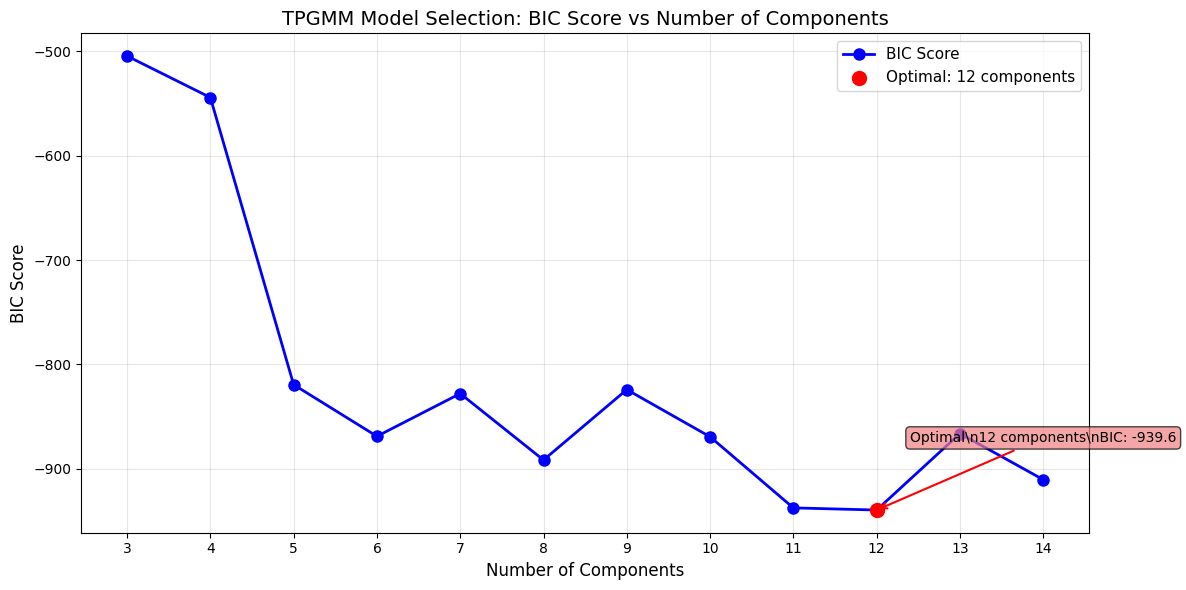

\n📊 BIC SCORES SUMMARY:
Components | BIC Score
----------------------------------------
    3      |  -504.4 
    4      |  -544.1 
    5      |  -819.4 
    6      |  -868.9 
    7      |  -827.9 
    8      |  -891.6 
    9      |  -824.1 
    10     |  -869.4 
    11     |  -937.5 
    12     |  -939.6  ⭐
    13     |  -866.2 
    14     |  -910.4 


In [ ]:
# Plot BIC scores for model selection visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot BIC scores
ax.plot(list(n_components_range), bic_scores, 'b-o', linewidth=2, markersize=8, label='BIC Score')
ax.scatter([best_n_components], [lowest_bic_score], color='red', s=100, zorder=5, label=f'Optimal: {best_n_components} components')

# Customize the plot
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('BIC Score', fontsize=12)
ax.set_title('TPGMM Model Selection: BIC Score vs Number of Components', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotation for the optimal point
ax.annotate(f'Optimal\\n{best_n_components} components\\nBIC: {lowest_bic_score:.1f}', 
            xy=(best_n_components, lowest_bic_score), 
            xytext=(best_n_components + 2, lowest_bic_score + (max(bic_scores) - min(bic_scores)) * 0.15),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

# Set x-axis ticks to show all tested components
ax.set_xticks(list(n_components_range))

plt.tight_layout()
plt.show()

# Display summary table
print("\\n📊 BIC SCORES SUMMARY:")
print("=" * 40)
print("Components | BIC Score")
print("-" * 40)
for i, (n_comp, bic) in enumerate(zip(n_components_range, bic_scores)):
    marker = " ⭐" if n_comp == best_n_components else ""
    print(f"{n_comp:^10} | {bic:^8.1f}{marker}")
print("=" * 40)

In [ ]:
print(f'\\nDefining TPGMM with the optimal n_components={best_n_components}...')
tpgmm = TPGMM(n_components=best_n_components, verbose=True, reg_factor=1e-8, threshold=1e-5)
print('Data check passed. Fitting the model...')
tpgmm.fit(reshaped_trajectories)

\nDefining TPGMM with the optimal n_components=12...
Data check passed. Fitting the model...
Started KMeans clustering
finished KMeans clustering
Start expectation maximization
Log likelihood: 677.60020236114 improvement 2653.1715594987754
Log likelihood: 615.8066417927332 improvement -61.79356056840675
Log likelihood: 573.4134012311422 improvement -42.39324056159103
Log likelihood: 542.6847370544037 improvement -30.728664176738448
Log likelihood: 519.7453744667463 improvement -22.939362587657456
Log likelihood: 502.3036042813639 improvement -17.44177018538238


frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, :2], covs=tpgmm.covariances_[frame_idx, :, :2, :2]
)
frame_idx = 1
plot_ellipsoids_2d(
   means=tpgmm.means_[frame_idx, :, :2], covs=tpgmm.covariances_[frame_idx, :, :2, :2]
)

<Axes: >

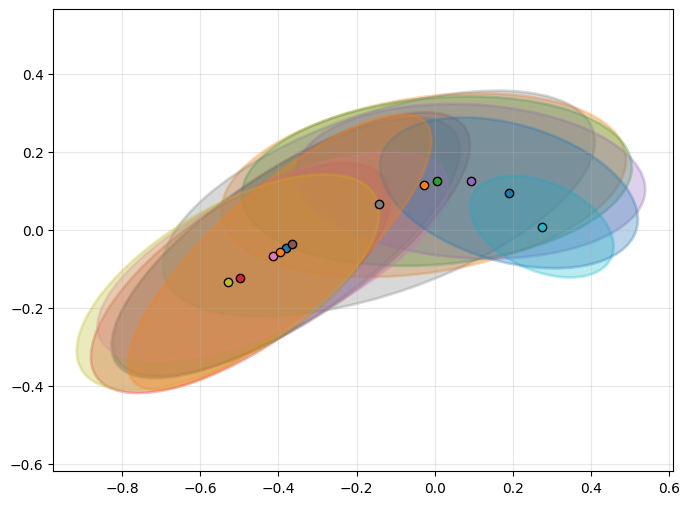

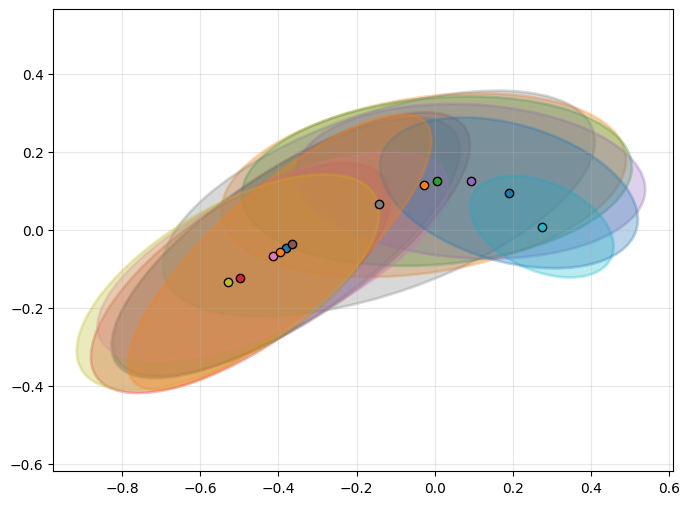

In [ ]:
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 2:4], covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4]
)
frame_idx = 1
plot_ellipsoids_2d(
   means=tpgmm.means_[frame_idx, :, 2:4], covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4]
)

Second Part - GMR